<a href="https://colab.research.google.com/github/Abdu1l-0/AIDC-W3-LABS/blob/W3D1/W3D1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# %%
# Cell: the pins and the installer function. Defines only, installs nothing.
# Paste this on every week-3 day. Then paste ONE of the two install cells below,
# whichever the day's README names. Day 1 profiles with transformers and must
# NOT install vLLM; days 2 to 5 serve, and must.
import subprocess, sys

# Pins mirrored from ../../../PINS.md. Keep these two in sync (PINS.md wins).
VLLM_PIN = "0.6.*"
BITSANDBYTES_PIN = "0.49.2"
AUTOAWQ_PIN = "0.2.*"
TRANSFORMERS_PIN = "4.46.*"
ACCELERATE_PIN = "1.1.*"
HTTPX_PIN = "0.27.*"
OPENAI_PIN = "1.54.*"

def pip_install(*specs):
    cmd = [sys.executable, "-m", "pip", "install", "-q", *specs]
    print("installing:", " ".join(specs))
    subprocess.run(cmd, check=True)



In [ ]:
# %%
# INSTALL CELL A: profiling only, NO SERVER. This is day 1.
#
# Day 1 loads the model with transformers and reads the card. It never serves,
# so it must NOT install vLLM. Installing vLLM here would replace Colab's torch
# with vLLM's older build AND downgrade numpy to 1.26, and Colab's preinstalled
# extensions are compiled against numpy 2. The model load then dies with
#   RuntimeError: Failed to import transformers.models.qwen2.modeling_qwen2
#   ... numpy.dtype size changed, Expected 96 from C header, got 88
# Verified on a T4, 2026-07-27. Colab's own torch is the torch today. This
# install is about two minutes, not thirty.
pip_install(
    f"transformers=={TRANSFORMERS_PIN}",
    f"accelerate=={ACCELERATE_PIN}",
    f"bitsandbytes=={BITSANDBYTES_PIN}",
)
print("profiling pins installed (no vLLM today)")

installing: transformers==4.46.* accelerate==1.1.* bitsandbytes==0.49.2
profiling pins installed (no vLLM today)


In [ ]:
!nvidia-smi --query-gpu=name,memory.total --format=csv,noheader
# expect: Tesla T4, 15360 MiB

Tesla T4, 15360 MiB


In [ ]:
import time, gc, torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

MODEL = "Qwen/Qwen2.5-1.5B-Instruct"
tok = AutoTokenizer.from_pretrained(MODEL)

def load(dtype: str):
    if dtype == "fp16":
        return AutoModelForCausalLM.from_pretrained(
            MODEL, torch_dtype=torch.float16, device_map="cuda")
    if dtype == "int8":
        qc = BitsAndBytesConfig(load_in_8bit=True)
        return AutoModelForCausalLM.from_pretrained(
            MODEL, quantization_config=qc, device_map="cuda")
    raise ValueError(dtype)

def make_prompt(context_tokens: int) -> str:
    # a filler prompt padded to about context_tokens input tokens
    base = "Summarise the following text in one sentence.\n"
    filler = ("The data center runs many small inference requests all day. " * 400)
    ids = tok(base + filler)["input_ids"][:context_tokens]
    return tok.decode(ids)

def resident_vram_gb() -> float:
    torch.cuda.synchronize()
    return torch.cuda.memory_reserved() / (1024 ** 3)

def profile(model, dtype: str, context: int, new_tokens: int = 128, batch: int = 1):
    prompt = make_prompt(context)
    prompts = [prompt] * batch
    enc = tok(prompts, return_tensors="pt", padding=True).to("cuda")
    # warm-up (compile/allocate), not measured
    _ = model.generate(**enc, max_new_tokens=8, do_sample=False)
    vram = resident_vram_gb()
    start_sampler()
    t0 = time.time()
    out = model.generate(**enc, max_new_tokens=new_tokens, do_sample=False)
    dt = time.time() - t0
    stop_sampler()
    gen_tokens = (out.shape[1] - enc["input_ids"].shape[1]) * batch
    return {
        "dtype": dtype,
        "context": context,
        "vram_gb": round(vram, 3),
        "util_mean": round(read_util_mean(), 1),
        "tokens_per_s": round(gen_tokens / dt, 1),
    }

def free_vram():
    """Hand freed memory back to the driver.

    Delete the model variable yourself first, in the cell, with `del model`.
    Passing it to a helper does not work: the helper deletes its own local name
    while your notebook variable still holds the weights, so nothing is freed
    and empty_cache() has nothing to give back.
    """
    gc.collect()
    torch.cuda.empty_cache()

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
import threading
import time
import pynvml

# Global state for the sampler
_sampling = False
_samples = []

def _sampler_thread():
    global _sampling, _samples
    pynvml.nvmlInit()
    handle = pynvml.nvmlDeviceGetHandleByIndex(0)
    while _sampling:
        util = pynvml.nvmlDeviceGetUtilizationRates(handle).gpu
        _samples.append(util)
        time.sleep(0.1)  # Sample every 100ms
    pynvml.nvmlShutdown()

def start_sampler():
    global _sampling, _samples
    _samples = []
    _sampling = True
    threading.Thread(target=_sampler_thread, daemon=True).start()

def stop_sampler():
    global _sampling
    _sampling = False
    time.sleep(0.2) # Wait for thread to finish last loop

def read_util_mean():
    if not _samples:
        return 0.0
    return sum(_samples) / len(_samples)

rows = []
for dtype in ["fp16", "int8"]:
    model = load(dtype)
    for context in [512, 2048, 4096]:
        row = profile(model, dtype, context)
        print(row)
        rows.append(row)
    del model      # without this the next dtype loads on top of this one
    free_vram()

/usr/local/lib/python3.13/dist-packages/transformers/generation/configuration_utils.py:590: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.7` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/transformers/generation/configuration_utils.py:595: UserWarning: `do_sample` is set to `False`. However, `top_p` is set to `0.8` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_p`.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/transformers/generation/configuration_utils.py:612: UserWarning: `do_sample` is set to `False`. However, `top_k` is set to `20` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_k`.
  warnings.warn(


{'dtype': 'fp16', 'context': 512, 'vram_gb': 3.113, 'util_mean': 52.3, 'tokens_per_s': 28.7}
{'dtype': 'fp16', 'context': 2048, 'vram_gb': 3.295, 'util_mean': 58.0, 'tokens_per_s': 23.7}
{'dtype': 'fp16', 'context': 4096, 'vram_gb': 3.568, 'util_mean': 86.0, 'tokens_per_s': 24.6}
{'dtype': 'int8', 'context': 512, 'vram_gb': 1.805, 'util_mean': 23.5, 'tokens_per_s': 5.3}
{'dtype': 'int8', 'context': 2048, 'vram_gb': 2.035, 'util_mean': 27.6, 'tokens_per_s': 5.2}
{'dtype': 'int8', 'context': 4096, 'vram_gb': 2.309, 'util_mean': 32.5, 'tokens_per_s': 4.9}


In [ ]:
model = load("fp16")
b1 = profile(model, "fp16", 512, new_tokens=128, batch=1)
b8 = profile(model, "fp16", 512, new_tokens=128, batch=8)
del model
free_vram()
print("batch 1:", b1)
print("batch 8:", b8)
print("tokens/s ratio:", round(b8["tokens_per_s"] / b1["tokens_per_s"], 2))
print("util delta:", round(b8["util_mean"] - b1["util_mean"], 1))
import json
with open("batch_check.json", "w") as f:
    json.dump({"batch1_tokens_per_s": b1["tokens_per_s"],
               "batch8_tokens_per_s": b8["tokens_per_s"]}, f, indent=2)

batch 1: {'dtype': 'fp16', 'context': 512, 'vram_gb': 3.113, 'util_mean': 50.5, 'tokens_per_s': 27.3}
batch 8: {'dtype': 'fp16', 'context': 512, 'vram_gb': 3.527, 'util_mean': 78.2, 'tokens_per_s': 188.2}
tokens/s ratio: 6.89
util delta: 27.7


In [ ]:
import json
with open("profile.json", "w") as f:
    json.dump(rows, f, indent=2)
print("wrote", len(rows), "rows to profile.json")

wrote 6 rows to profile.json


In [ ]:
# Green-check verifier for Lab W3D1 (profile inference).
# Paste this as the last cell of your day-1 notebook and run it. It reads
# profile.json (the matrix rows you wrote) and checks the schema and the sanity
# rules. It also reads the batch experiment numbers if you saved them to
# batch_check.json; if that file is absent it asks for the two numbers inline so
# the batch-8 > batch-1 rule can still be checked.
#
# Last line is exactly one of:
#   GREEN CHECK: PASS
#   GREEN CHECK: FAIL (<reason>)
# No interactivity, no arguments; exit code matches.

import json, os

REQUIRED_KEYS = {"dtype", "context", "vram_gb", "util_mean", "tokens_per_s"}


class _Stop(Exception):
    """Ends the check without killing the notebook kernel."""


def fail(reason: str) -> "NoReturn":
    print(f"GREEN CHECK: FAIL ({reason})")
    raise _Stop()


def load_json(path: str):
    if not os.path.exists(path):
        fail(f"{path} not found; write it in the last data cell")
    try:
        with open(path) as fh:
            return json.load(fh)
    except json.JSONDecodeError as exc:
        fail(f"{path} is not valid JSON: {exc}")


def main() -> None:
    rows = load_json("profile.json")

    if not isinstance(rows, list) or not rows:
        fail("profile.json must be a non-empty list of rows")

    # schema
    for i, row in enumerate(rows):
        if not isinstance(row, dict):
            fail(f"row {i} is not an object")
        missing = REQUIRED_KEYS - set(row)
        if missing:
            fail(f"row {i} missing keys: {sorted(missing)}")

    dtypes = {r["dtype"] for r in rows}
    contexts = sorted({r["context"] for r in rows})
    if "fp16" not in dtypes:
        fail("no fp16 rows; the matrix needs fp16")
    if len(contexts) < 3:
        fail(f"need at least 3 context lengths, found {contexts}")

    # sanity 1: VRAM rises with context (within each dtype)
    for dt in dtypes:
        sub = sorted((r for r in rows if r["dtype"] == dt),
                     key=lambda r: r["context"])
        vrams = [r["vram_gb"] for r in sub]
        if any(b < a - 0.01 for a, b in zip(vrams, vrams[1:])):
            fail(f"{dt} VRAM does not rise with context: {vrams}")

    # sanity 2: fp16 uses more memory than int8 at a shared context
    if "int8" in dtypes:
        shared = None
        for c in contexts:
            has_fp16 = any(r["dtype"] == "fp16" and r["context"] == c for r in rows)
            has_int8 = any(r["dtype"] == "int8" and r["context"] == c for r in rows)
            if has_fp16 and has_int8:
                shared = c
                break
        if shared is None:
            fail("fp16 and int8 share no context length to compare")
        fp16_v = next(r["vram_gb"] for r in rows
                      if r["dtype"] == "fp16" and r["context"] == shared)
        int8_v = next(r["vram_gb"] for r in rows
                      if r["dtype"] == "int8" and r["context"] == shared)
        if not fp16_v > int8_v:
            fail(f"fp16 VRAM ({fp16_v}) not above int8 VRAM ({int8_v}) at "
                 f"context {shared}")

    # sanity 3: batch-8 tokens/s beats batch-1
    b1 = b8 = None
    if os.path.exists("batch_check.json"):
        bc = load_json("batch_check.json")
        b1 = bc.get("batch1_tokens_per_s")
        b8 = bc.get("batch8_tokens_per_s")
    else:
        # allow the two numbers as module-level names set in an earlier cell
        b1 = globals().get("BATCH1_TOKENS_PER_S")
        b8 = globals().get("BATCH8_TOKENS_PER_S")
    if b1 is None or b8 is None:
        fail("batch numbers missing; save batch_check.json with "
             "batch1_tokens_per_s and batch8_tokens_per_s, or set "
             "BATCH1_TOKENS_PER_S / BATCH8_TOKENS_PER_S")
    if not b8 > b1:
        fail(f"batch-8 tokens/s ({b8}) not above batch-1 ({b1})")

    print(f"rows: {len(rows)}, dtypes: {sorted(dtypes)}, contexts: {contexts}")
    print(f"batch-1 tokens/s: {b1}, batch-8 tokens/s: {b8}")
    print("GREEN CHECK: PASS")


try:
    main()
except _Stop:
    # A notebook cell cannot exit nonzero without printing a red traceback over
    # the result line, so only signal by exit code when run as a plain script.
    try:
        get_ipython()  # defined only inside IPython/Colab
    except NameError:
        raise SystemExit(1)


rows: 6, dtypes: ['fp16', 'int8'], contexts: [512, 2048, 4096]
batch-1 tokens/s: 27.3, batch-8 tokens/s: 188.2
GREEN CHECK: PASS


In [ ]:
import json

# Load data from the saved JSON files
with open('profile.json', 'r') as f:
    profile_rows = json.load(f)

with open('batch_check.json', 'r') as f:
    batch_data = json.load(f)

# Format the content for the markdown file
md_content = "# LLM Inference Profiling Results\n\n"
md_content += "## Model Matrix (VRAM and Throughput)\n"
md_content += "| Dtype | Context | VRAM (GB) | Util (%) | Tokens/s |\n"
md_content += "|-------|---------|-----------|----------|----------|\n"
for r in profile_rows:
    md_content += f"| {r['dtype']} | {r['context']} | {r['vram_gb']} | {r['util_mean']} | {r['tokens_per_s']} |\n"

md_content += "\n## Batch Experiment (fp16, 512 context)\n"
md_content += f"- **Batch 1 Tokens/s:** {batch_data['batch1_tokens_per_s']}\n"
md_content += f"- **Batch 8 Tokens/s:** {batch_data['batch8_tokens_per_s']}\n"
md_content += f"- **Throughput Ratio:** {round(batch_data['batch8_tokens_per_s'] / batch_data['batch1_tokens_per_s'], 2)}x\n"

# Write to output.md
with open('output.md', 'w') as f:
    f.write(md_content)

print("Successfully extracted results to output.md")

Successfully extracted results to output.md


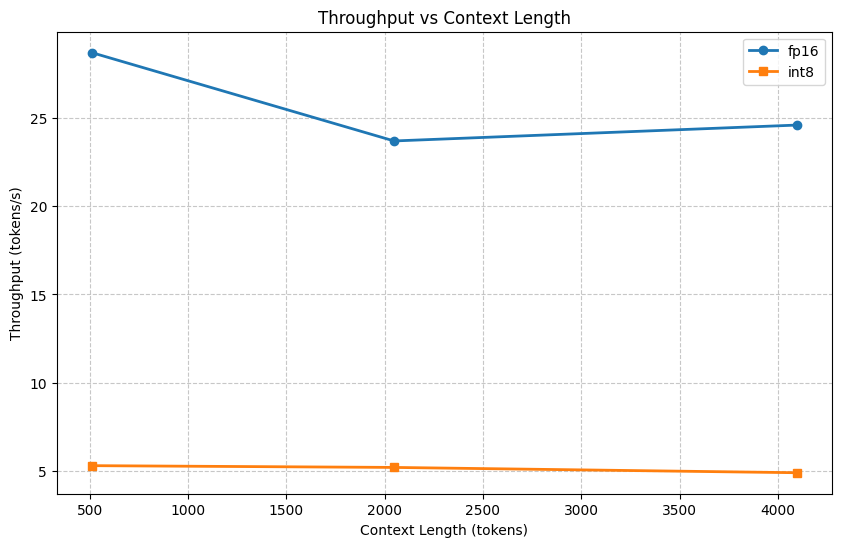

In [ ]:
import matplotlib.pyplot as plt

# Extract data for plotting
fp16_data = [r for r in profile_rows if r['dtype'] == 'fp16']
int8_data = [r for r in profile_rows if r['dtype'] == 'int8']

plt.figure(figsize=(10, 6))

# Plot fp16 throughput
plt.plot([r['context'] for r in fp16_data], [r['tokens_per_s'] for r in fp16_data],
         marker='o', label='fp16', linewidth=2)

# Plot int8 throughput
plt.plot([r['context'] for r in int8_data], [r['tokens_per_s'] for r in int8_data],
         marker='s', label='int8', linewidth=2)

plt.title('Throughput vs Context Length')
plt.xlabel('Context Length (tokens)')
plt.ylabel('Throughput (tokens/s)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

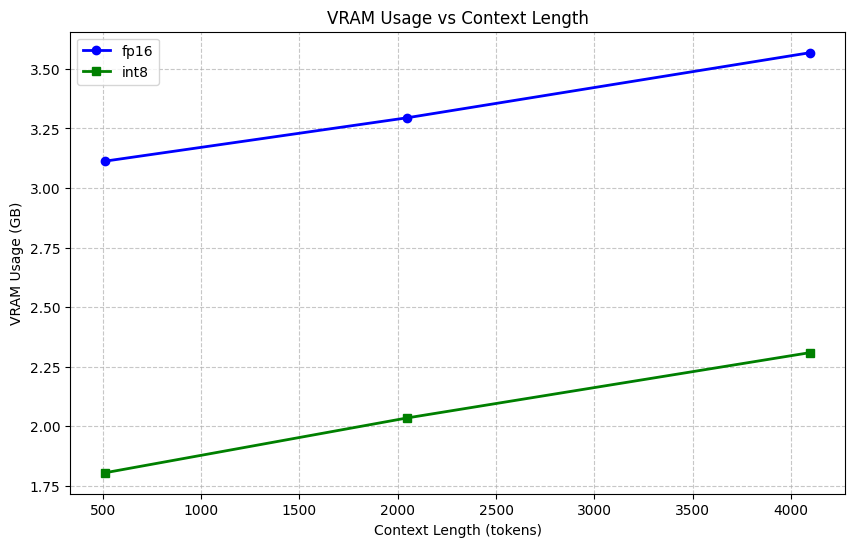

In [ ]:
import matplotlib.pyplot as plt

# Data is already prepared in fp16_data and int8_data from the previous cell
plt.figure(figsize=(10, 6))

# Plot fp16 VRAM
plt.plot([r['context'] for r in fp16_data], [r['vram_gb'] for r in fp16_data],
         marker='o', label='fp16', linewidth=2, color='blue')

# Plot int8 VRAM
plt.plot([r['context'] for r in int8_data], [r['vram_gb'] for r in int8_data],
         marker='s', label='int8', linewidth=2, color='green')

plt.title('VRAM Usage vs Context Length')
plt.xlabel('Context Length (tokens)')
plt.ylabel('VRAM Usage (GB)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [ ]:
from google.colab import files
for f_ in ["profile.json", "batch_check.json"]:
    files.download(f_)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>